In [1]:
import pandas as pd
from pathlib import Path

count_matrix = pd.read_csv(
    "data/processed/tcga_brca_raw_unstranded_counts_sample_level.csv",
    index_col=0
)

gene_annotation = pd.read_csv(
    "data/processed/tcga_brca_gene_annotation_from_star_counts.csv"
)

metadata = pd.read_csv(
    "data/metadata/tcga_brca_sample_level_dedup.csv"
)

count_matrix.shape, gene_annotation.shape, metadata.shape

((60660, 1219), (60660, 3), (1219, 9))

In [2]:
set(count_matrix.columns) == set(metadata["sample_barcode"])

True

In [3]:
qc = metadata.copy()

library_sizes = count_matrix.sum(axis=0)

qc["library_size"] = qc["sample_barcode"].map(library_sizes)

In [4]:
qc["library_size"].describe()

count    1.219000e+03
mean     5.801554e+07
std      1.459996e+07
min      1.922512e+07
25%      4.771004e+07
50%      5.765274e+07
75%      6.831718e+07
max      1.140157e+08
Name: library_size, dtype: float64

In [5]:
qc.groupby("sample_group")["library_size"].describe()

,count,mean,std,min,25%,50%,75%,max
sample_group,,,,,,,,
normal,113.0,5.746317e+07,1.354615e+07,29273747.0,47703689.0,55884898.0,67304826.0,99434546.0
tumor,1106.0,5.807198e+07,1.470795e+07,19225117.0,47717104.0,57792728.5,68437363.5,114015705.0


In [6]:
detected_genes = (count_matrix > 0).sum(axis=0)

qc["detected_genes"] = qc["sample_barcode"].map(detected_genes)
qc["detected_genes"].describe()

count     1219.000000
mean     32676.812961
std       2606.739831
min      24322.000000
25%      31275.500000
50%      32643.000000
75%      33960.000000
max      54681.000000
Name: detected_genes, dtype: float64

In [7]:
qc.groupby("sample_group")["detected_genes"].describe()

,count,mean,std,min,25%,50%,75%,max
sample_group,,,,,,,,
normal,113.0,33556.389381,2411.646949,26954.0,31883.00,33532.0,35424.0,38580.0
tumor,1106.0,32586.946655,2610.225480,24322.0,31226.75,32586.5,33817.0,54681.0


In [8]:
qc_dir = Path("results/qc")
qc_dir.mkdir(parents=True, exist_ok=True)

qc.to_csv(
    qc_dir / "tcga_brca_sample_qc_library_size_detected_genes.csv",
    index=False
)

<Figure size 700x500 with 0 Axes>

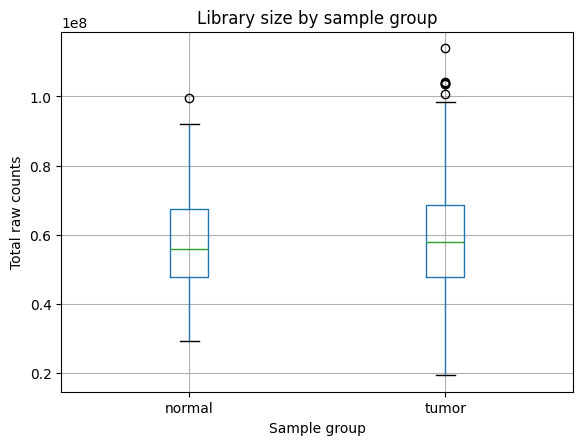

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
qc.boxplot(column="library_size", by="sample_group")
plt.title("Library size by sample group")
plt.suptitle("")
plt.ylabel("Total raw counts")
plt.xlabel("Sample group")
plt.show()

<Figure size 700x500 with 0 Axes>

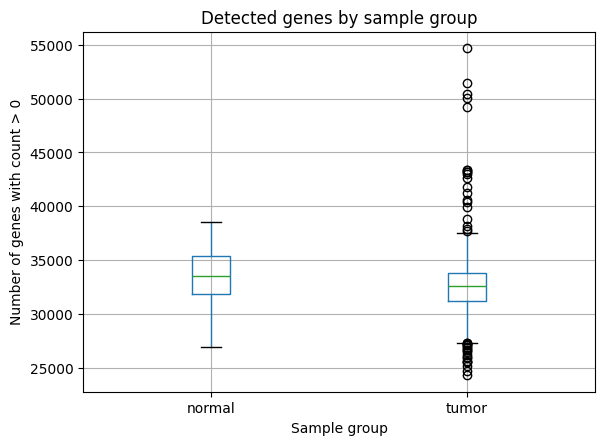

In [10]:
plt.figure(figsize=(7, 5))
qc.boxplot(column="detected_genes", by="sample_group")
plt.title("Detected genes by sample group")
plt.suptitle("")
plt.ylabel("Number of genes with count > 0")
plt.xlabel("Sample group")
plt.show()

<Figure size 700x500 with 0 Axes>

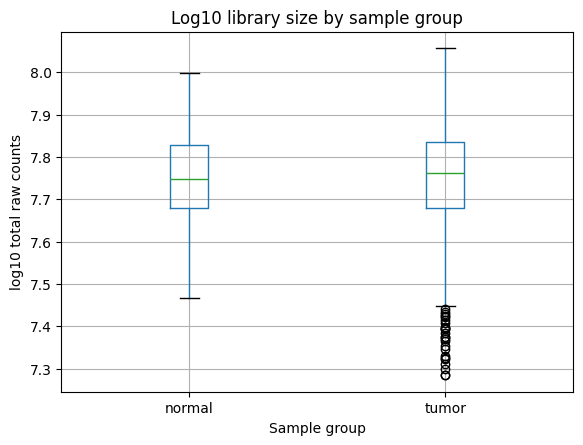

In [11]:
import numpy as np

qc["log10_library_size"] = np.log10(qc["library_size"])

plt.figure(figsize=(7, 5))
qc.boxplot(column="log10_library_size", by="sample_group")
plt.title("Log10 library size by sample group")
plt.suptitle("")
plt.ylabel("log10 total raw counts")
plt.xlabel("Sample group")
plt.show()

In [12]:
qc.sort_values("library_size").head(10)[
    ["sample_barcode", "patient_barcode", "sample_group", "library_size", "detected_genes"]
]

,sample_barcode,patient_barcode,sample_group,library_size,detected_genes
152,TCGA-A7-A26E-01B,TCGA-A7-A26E,tumor,19225117,37548
1189,TCGA-OL-A6VQ-01A,TCGA-OL-A6VQ,tumor,19303211,28172
135,TCGA-A7-A0DB-01C,TCGA-A7-A0DB,tumor,19921888,37219
293,TCGA-AC-A3OD-01B,TCGA-AC-A3OD,tumor,20397101,38830
160,TCGA-A7-A26J-01B,TCGA-A7-A26J,tumor,20981149,41828
286,TCGA-AC-A2QH-01B,TCGA-AC-A2QH,tumor,21150195,37284
1129,TCGA-GM-A2DO-01A,TCGA-GM-A2DO,tumor,21317570,30741
141,TCGA-A7-A13D-01B,TCGA-A7-A13D,tumor,22225059,54681
2,TCGA-3C-AALJ-01A,TCGA-3C-AALJ,tumor,22598154,29665
699,TCGA-BH-A1ES-01A,TCGA-BH-A1ES,tumor,23194341,28614


In [13]:
qc.sort_values("detected_genes").head(10)[
    ["sample_barcode", "patient_barcode", "sample_group", "library_size", "detected_genes"]
]

,sample_barcode,patient_barcode,sample_group,library_size,detected_genes
320,TCGA-AN-A03X-01A,TCGA-AN-A03X,tumor,36378914,24322
621,TCGA-BH-A0DZ-01A,TCGA-BH-A0DZ,tumor,26006524,24722
669,TCGA-BH-A18G-01A,TCGA-BH-A18G,tumor,38201082,25186
254,TCGA-A8-A09T-01A,TCGA-A8-A09T,tumor,23745717,25571
1039,TCGA-E9-A226-01A,TCGA-E9-A226,tumor,59637526,25584
218,TCGA-A8-A08B-01A,TCGA-A8-A08B,tumor,23466090,25696
783,TCGA-C8-A133-01A,TCGA-C8-A133,tumor,49138448,25949
361,TCGA-AO-A03N-01B,TCGA-AO-A03N,tumor,54238724,26053
196,TCGA-A8-A07B-01A,TCGA-A8-A07B,tumor,26586182,26243
786,TCGA-C8-A137-01A,TCGA-C8-A137,tumor,40724218,26528


In [14]:
qc.sort_values("library_size", ascending=False).head(10)[
    ["sample_barcode", "patient_barcode", "sample_group", "library_size", "detected_genes"]
]

,sample_barcode,patient_barcode,sample_group,library_size,detected_genes
946,TCGA-E2-A1B0-01A,TCGA-E2-A1B0,tumor,114015705,33266
248,TCGA-A8-A09I-01A,TCGA-A8-A09I,tumor,104167219,34392
465,TCGA-AR-A251-01A,TCGA-AR-A251,tumor,103906260,38141
947,TCGA-E2-A1B1-01A,TCGA-E2-A1B1,tumor,103733006,37739
1049,TCGA-E9-A243-01A,TCGA-E9-A243,tumor,103495522,36732
938,TCGA-E2-A15M-01A,TCGA-E2-A15M,tumor,100608368,36793
698,TCGA-BH-A1EO-11A,TCGA-BH-A1EO,normal,99434546,31423
702,TCGA-BH-A1EU-01A,TCGA-BH-A1EU,tumor,98266886,37876
884,TCGA-D8-A27V-01A,TCGA-D8-A27V,tumor,97239275,34941
223,TCGA-A8-A08I-01A,TCGA-A8-A08I,tumor,96774371,37068


In [15]:
protein_coding_ids = set(
    gene_annotation.loc[
        gene_annotation["gene_type"] == "protein_coding",
        "gene_id"
    ]
)

counts_pc = count_matrix.loc[count_matrix.index.isin(protein_coding_ids)]

counts_pc.shape

(19962, 1219)

In [16]:
keep_genes = (counts_pc >= 10).sum(axis=1) >= 10

counts_pc_filtered = counts_pc.loc[keep_genes]

counts_pc_filtered.shape

(18181, 1219)

In [17]:
log_counts = np.log2(counts_pc_filtered + 1)

In [18]:
top_variable_genes = log_counts.var(axis=1).sort_values(ascending=False).head(5000).index

log_counts_top = log_counts.loc[top_variable_genes]

In [19]:
X = log_counts_top.T

In [20]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pcs = pca.fit_transform(X)

pca_df = pd.DataFrame(
    pcs,
    columns=["PC1", "PC2"],
    index=X.index
)

pca_df = pca_df.merge(
    metadata[["sample_barcode", "sample_group"]],
    left_index=True,
    right_on="sample_barcode"
)

pca.explained_variance_ratio_

array([0.13547059, 0.10634089])

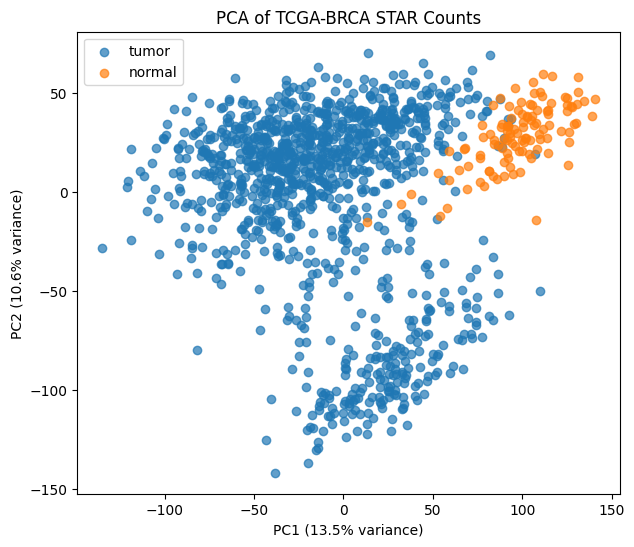

In [21]:
plt.figure(figsize=(7, 6))

for group in pca_df["sample_group"].unique():
    subset = pca_df[pca_df["sample_group"] == group]
    plt.scatter(subset["PC1"], subset["PC2"], label=group, alpha=0.7)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")
plt.title("PCA of TCGA-BRCA STAR Counts")
plt.legend()
plt.show()

In [28]:
sample = "TCGA-A7-A13D-01B"

sample_counts = count_matrix[sample]

summary = pd.Series({
    "total_counts": sample_counts.sum(),
    "detected_genes_count_gt_0": (sample_counts > 0).sum(),
    "genes_count_eq_1": (sample_counts == 1).sum(),
    "genes_count_le_5": (sample_counts <= 5).sum(),
    "genes_count_le_5_and_gt_0": ((sample_counts <= 5) & (sample_counts > 0)).sum(),
    "genes_count_eq_0": (sample_counts == 0).sum(),
})

summary

total_counts                 22225059
detected_genes_count_gt_0       54681
genes_count_eq_1                 2546
genes_count_le_5                18010
genes_count_le_5_and_gt_0       12031
genes_count_eq_0                 5979
dtype: int64

In [29]:
median_detected_sample = (
    qc[qc["sample_group"] == "tumor"]
    .assign(distance_from_median = lambda d: 
            (d["detected_genes"] - d["detected_genes"].median()).abs())
    .sort_values("distance_from_median")
    .iloc[0]["sample_barcode"]
)

median_detected_sample

'TCGA-C8-A1HO-01A'

In [30]:
sample = median_detected_sample
sample_counts = count_matrix[sample]

summary = pd.Series({
    "total_counts": sample_counts.sum(),
    "detected_genes_count_gt_0": (sample_counts > 0).sum(),
    "genes_count_eq_1": (sample_counts == 1).sum(),
    "genes_count_le_5": (sample_counts <= 5).sum(),
    "genes_count_le_5_and_gt_0": ((sample_counts <= 5) & (sample_counts > 0)).sum(),
    "genes_count_eq_0": (sample_counts == 0).sum(),
})

summary

total_counts                 66232342
detected_genes_count_gt_0       32580
genes_count_eq_1                 4506
genes_count_le_5                38140
genes_count_le_5_and_gt_0       10060
genes_count_eq_0                28080
dtype: int64

In [31]:
def add_iqr_flags(df, column, group_col="sample_group", k=1.5):
    df = df.copy()
    
    low_flag = f"qc_flag_low_{column}"
    high_flag = f"qc_flag_high_{column}"
    
    df[low_flag] = False
    df[high_flag] = False
    
    for group, sub in df.groupby(group_col):
        q1 = sub[column].quantile(0.25)
        q3 = sub[column].quantile(0.75)
        iqr = q3 - q1
        
        low_cutoff = q1 - k * iqr
        high_cutoff = q3 + k * iqr
        
        idx = sub.index
        
        df.loc[idx, low_flag] = df.loc[idx, column] < low_cutoff
        df.loc[idx, high_flag] = df.loc[idx, column] > high_cutoff
        
        print(group, column)
        print("  low cutoff: ", low_cutoff)
        print("  high cutoff:", high_cutoff)
        print()
    
    return df

qc = add_iqr_flags(qc, "library_size")
qc = add_iqr_flags(qc, "detected_genes")

normal library_size
  low cutoff:  18301983.5
  high cutoff: 96706531.5

tumor library_size
  low cutoff:  16636714.75
  high cutoff: 99517752.75

normal detected_genes
  low cutoff:  26571.5
  high cutoff: 40735.5

tumor detected_genes
  low cutoff:  27341.375
  high cutoff: 37702.375



In [32]:
flag_cols = [
    "qc_flag_low_library_size",
    "qc_flag_high_library_size",
    "qc_flag_low_detected_genes",
    "qc_flag_high_detected_genes",
]

qc[flag_cols].sum()

qc_flag_low_library_size        0
qc_flag_high_library_size       7
qc_flag_low_detected_genes     19
qc_flag_high_detected_genes    20
dtype: int64

In [33]:
qc["qc_flag_any_basic"] = qc[flag_cols].any(axis=1)

qc["qc_flag_any_basic"].value_counts()

qc_flag_any_basic
False    1175
True       44
Name: count, dtype: int64

In [34]:
qc.loc[
    qc["qc_flag_any_basic"],
    [
        "sample_barcode",
        "patient_barcode",
        "sample_group",
        "library_size",
        "detected_genes",
        *flag_cols
    ]
].sort_values(["sample_group", "library_size"])

,sample_barcode,patient_barcode,sample_group,library_size,detected_genes,qc_flag_low_library_size,qc_flag_high_library_size,qc_flag_low_detected_genes,qc_flag_high_detected_genes
698,TCGA-BH-A1EO-11A,TCGA-BH-A1EO,normal,99434546,31423,False,True,False,False
293,TCGA-AC-A3OD-01B,TCGA-AC-A3OD,tumor,20397101,38830,False,False,False,True
160,TCGA-A7-A26J-01B,TCGA-A7-A26J,tumor,20981149,41828,False,False,False,True
141,TCGA-A7-A13D-01B,TCGA-A7-A13D,tumor,22225059,54681,False,False,False,True
218,TCGA-A8-A08B-01A,TCGA-A8-A08B,tumor,23466090,25696,False,False,True,False
254,TCGA-A8-A09T-01A,TCGA-A8-A09T,tumor,23745717,25571,False,False,True,False
143,TCGA-A7-A13E-01B,TCGA-A7-A13E,tumor,24791868,39941,False,False,False,True
138,TCGA-A7-A0DC-01B,TCGA-A7-A0DC,tumor,24969153,40554,False,False,False,True
621,TCGA-BH-A0DZ-01A,TCGA-BH-A0DZ,tumor,26006524,24722,False,False,True,False
196,TCGA-A8-A07B-01A,TCGA-A8-A07B,tumor,26586182,26243,False,False,True,False


In [35]:
flag_cols = [
    "qc_flag_low_library_size",
    "qc_flag_high_library_size",
    "qc_flag_low_detected_genes",
    "qc_flag_high_detected_genes",
]

qc["qc_flag_any"] = qc[flag_cols].any(axis=1)

def qc_reasons(row):
    reasons = []
    if row["qc_flag_low_library_size"]:
        reasons.append("low_library_size")
    if row["qc_flag_high_library_size"]:
        reasons.append("high_library_size")
    if row["qc_flag_low_detected_genes"]:
        reasons.append("low_detected_genes")
    if row["qc_flag_high_detected_genes"]:
        reasons.append("high_detected_genes")
    return ";".join(reasons)

qc["qc_flag_reasons"] = qc.apply(qc_reasons, axis=1)

qc.to_csv(
    "results/qc/tcga_brca_sample_qc_library_size_detected_genes_flagged.csv",
    index=False
)

In [37]:
print(qc["qc_flag_any"].value_counts())
print(qc.groupby("sample_group")["qc_flag_any"].agg(["sum", "count", "mean"]))

qc_flag_any
False    1175
True       44
Name: count, dtype: int64
              sum  count      mean
sample_group                      
normal          1    113  0.008850
tumor          43   1106  0.038879


In [38]:
pca_df = pca_df.merge(
    qc[["sample_barcode", "qc_flag_any", "qc_flag_reasons"]],
    on="sample_barcode",
    how="left"
)

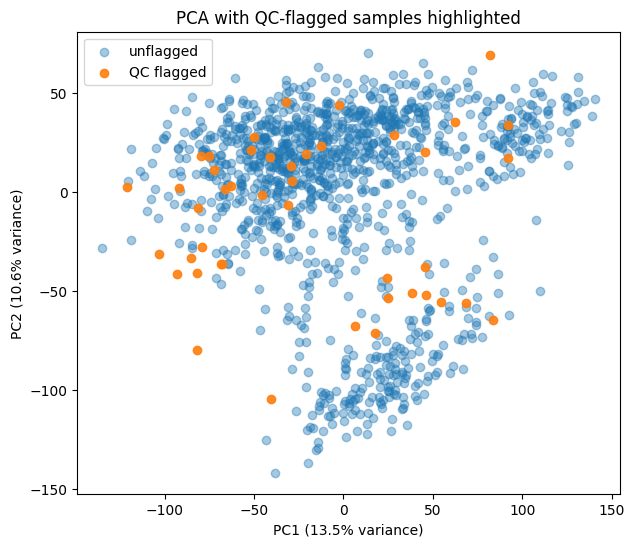

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

unflagged = pca_df[~pca_df["qc_flag_any"]]
flagged = pca_df[pca_df["qc_flag_any"]]

plt.scatter(
    unflagged["PC1"],
    unflagged["PC2"],
    alpha=0.4,
    label="unflagged"
)

plt.scatter(
    flagged["PC1"],
    flagged["PC2"],
    alpha=0.9,
    label="QC flagged"
)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")
plt.title("PCA with QC-flagged samples highlighted")
plt.legend()
plt.show()

### PCA with QC flags

QC-flagged samples were overlaid on the PCA to determine whether library-size or detected-gene outliers form a distinct technical cluster. Flagged samples were scattered across the tumor distribution rather than forming a separate cluster. Only 44/1219 samples were flagged by the basic group-wise IQR rules, including 43/1106 tumors and 1/113 normals. Because flagged samples do not appear to drive a distinct PCA structure, they were retained for downstream analysis and will be tracked for later sensitivity analyses.

In [40]:
pca_df.to_csv(
    "results/qc/tcga_brca_pca_scores_sample_level_qc_overlay.csv",
    index=False
)

qc.to_csv(
    "results/qc/tcga_brca_sample_qc_library_size_detected_genes_flagged.csv",
    index=False
)